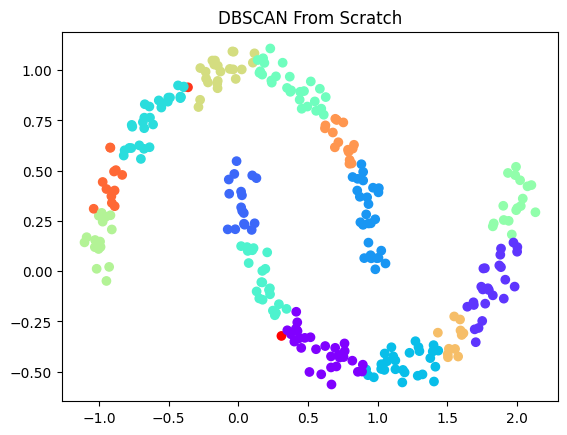

In [14]:
#DBSCAN FROM SCRATCH
# =========================
# IMPORTATION DES LIBRARIES
# =========================

import numpy as np                         # Manipulation des tableaux numériques
import matplotlib.pyplot as plt            # Affichage des graphiques
from sklearn.datasets import make_moons    # Génération d'un dataset de test

# =========================
# CREATION DU DATASET
# =========================

# Création d'un dataset non linéaire
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

# =========================
# FONCTION DISTANCE EUCLIDIENNE
# =========================

# Fonction qui calcule la distance entre deux points
# Formule : sqrt((x2-x1)^2 + (y2-y1)^2)
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))

# =========================
# CLASSE DBSCAN
# =========================

class DBSCAN_FromScratch:

    # Constructeur de la classe
    def __init__(self, eps=0.3, min_points=5):
        self.eps = eps                    # Rayon de voisinage
        self.min_points = min_points      # Nombre minimal de voisins

    # Fonction qui trouve les voisins d'un point
    def get_neighbors(self, X, index):

        neighbors = []

        # Parcours de tous les points du dataset
        for i in range(len(X)):

            # Calcul de la distance entre les points
            distance = euclidean_distance(X[index], X[i])

            # Vérification si la distance est dans le rayon eps
            if distance <= self.eps:
                neighbors.append(i)

        return neighbors

    # Fonction principale d'entraînement
    def fit(self, X):

        # Initialisation des labels à -1 (bruit)
        self.labels = [-1] * len(X)

        # Variable pour numéroter les clusters
        cluster_id = 0

        # Parcours des points
        for point_index in range(len(X)):

            # Ignorer les points déjà visités
            if self.labels[point_index] != -1:
                continue

            # Récupération des voisins
            neighbors = self.get_neighbors(X, point_index)

            # Vérification du nombre minimal de voisins
            if len(neighbors) < self.min_points:
                self.labels[point_index] = -1
            else:

                # Création d'un nouveau cluster
                self.expand_cluster(X, point_index, neighbors, cluster_id)

                # Passage au cluster suivant
                cluster_id += 1

    # Fonction d'expansion du cluster
    def expand_cluster(self, X, point_index, neighbors, cluster_id):

        # Attribution du cluster au point actuel
        self.labels[point_index] = cluster_id

        # Index pour parcourir les voisins
        i = 0

        while i < len(neighbors):

            neighbor_point = neighbors[i]

            # Si le point est considéré comme bruit
            if self.labels[neighbor_point] == -1:
                self.labels[neighbor_point] = cluster_id

            # Si le point n'a pas encore été visité
            elif self.labels[neighbor_point] == -1:
                self.labels[neighbor_point] = cluster_id

                # Recherche des nouveaux voisins
                new_neighbors = self.get_neighbors(X, neighbor_point)

                # Vérification du nombre minimal de voisins
                if len(new_neighbors) >= self.min_points:
                    neighbors += new_neighbors

            i += 1

# =========================
# ENTRAINEMENT DU MODELE
# =========================

# Création du modèle
model = DBSCAN_FromScratch(eps=0.3, min_points=5)

# Entraînement du modèle
model.fit(X)

# =========================
# VISUALISATION DES RESULTATS
# =========================

# Affichage des clusters
plt.scatter(X[:, 0], X[:, 1], c=model.labels, cmap='rainbow')
plt.title("DBSCAN From Scratch")
plt.show()

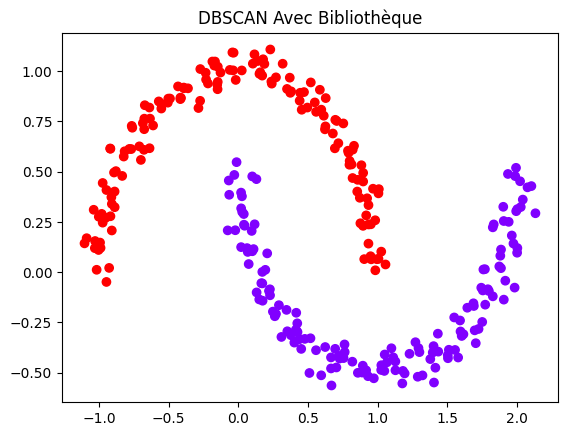

In [15]:
# DBSCAN AVEC BIBLIOTHEQUE


# =========================
# IMPORTATION DES LIBRARIES
# =========================

from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# =========================
# CREATION DU DATASET
# =========================

X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

# =========================
# CREATION DU MODELE
# =========================

model = DBSCAN(eps=0.3, min_samples=5)

# =========================
# ENTRAINEMENT DU MODELE
# =========================

labels = model.fit_predict(X)

# =========================
# VISUALISATION
# =========================

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow')
plt.title("DBSCAN Avec Bibliothèque")
plt.show()

In [16]:
# NAIVE BAYES FROM SCRATCH


# =========================
# IMPORTATION DES LIBRARIES
# =========================

import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# =========================
# CHARGEMENT DU DATASET
# =========================

iris = load_iris()
X = iris.data
y = iris.target

# =========================
# DIVISION DU DATASET
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# CLASSE NAIVE BAYES
# =========================

class NaiveBayes:

    # Fonction d'entraînement
    def fit(self, X, y):

        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.priors = {}

        # Calcul des paramètres pour chaque classe
        for c in self.classes:

            X_c = X[y == c]

            self.mean[c] = np.mean(X_c, axis=0)
            self.var[c] = np.var(X_c, axis=0)
            self.priors[c] = X_c.shape[0] / X.shape[0]

    # Fonction de densité gaussienne
    def gaussian_density(self, class_idx, x):

        mean = self.mean[class_idx]
        var = self.var[class_idx]

        numerator = np.exp(- ((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)

        return numerator / denominator

    # Fonction de prédiction
    def predict(self, X):

        predictions = []

        for x in X:

            posteriors = []

            for c in self.classes:

                prior = np.log(self.priors[c])
                conditional = np.sum(np.log(self.gaussian_density(c, x)))

                posterior = prior + conditional

                posteriors.append(posterior)

            predictions.append(np.argmax(posteriors))

        return predictions

# =========================
# ENTRAINEMENT
# =========================

model = NaiveBayes()
model.fit(X_train, y_train)

# =========================
# PREDICTIONS
# =========================

predictions = model.predict(X_test)

# =========================
# EVALUATION
# =========================

accuracy = accuracy_score(y_test, predictions)

print("Accuracy :", accuracy)

Accuracy : 1.0


In [17]:
# NAIVE BAYES AVEC BIBLIOTHEQUE

# =========================
# IMPORTATION DES LIBRARIES
# =========================

from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# =========================
# CHARGEMENT DU DATASET
# =========================

iris = load_iris()
X = iris.data
y = iris.target

# =========================
# DIVISION DU DATASET
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# CREATION DU MODELE
# =========================

model = GaussianNB()

# =========================
# ENTRAINEMENT
# =========================

model.fit(X_train, y_train)

# =========================
# PREDICTIONS
# =========================

predictions = model.predict(X_test)

# =========================
# EVALUATION
# =========================

accuracy = accuracy_score(y_test, predictions)

print("Accuracy :", accuracy)

Accuracy : 1.0


========== XGBOOST FROM SCRATCH ==========
Shape X : (100, 1)
Shape y : (100,)


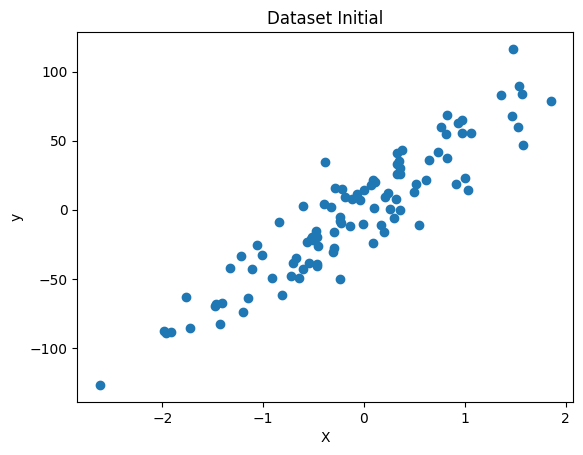

Valeur moyenne initiale : -2.5643921521384936
Premiers résidus :
[ 65.25159415 -21.19958857 -23.12237367  10.50084869 -12.91110239
  38.65835092 -38.22980894  -8.25864708  23.97909914  25.36301427]
Erreur après arbre 1 : 1798.795757062492
Erreur après arbre 2 : 1533.0163634477603


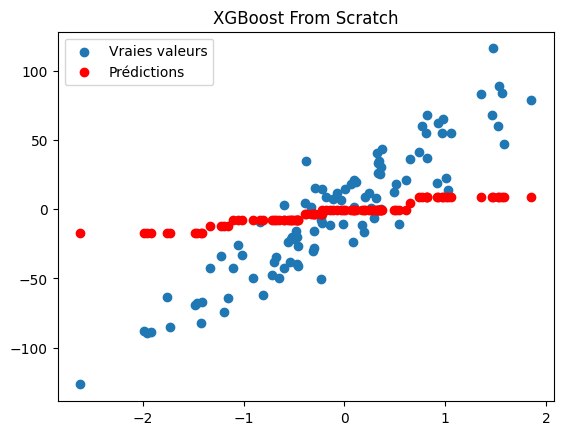

In [18]:
# XGBOOST FROM SCRATCH

# =========================================================
# IMPORTATION DES BIBLIOTHEQUES
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
from sklearn.datasets import make_regression
from sklearn.datasets import load_iris

# Outils Machine Learning
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# XGBoost
from xgboost import XGBRegressor


# =========================================================
# PARTIE 1 : XGBOOST FROM SCRATCH
# =========================================================

print("========== XGBOOST FROM SCRATCH ==========")

# ---------------------------------------------------------
# CREATION DU DATASET
# ---------------------------------------------------------

# Création des données de régression
X, y = make_regression(
    n_samples=100,      # Nombre d'exemples
    n_features=1,       # Une seule variable
    noise=20,           # Bruit
    random_state=42     # Reproductibilité
)

# Affichage des dimensions
print("Shape X :", X.shape)
print("Shape y :", y.shape)

# ---------------------------------------------------------
# VISUALISATION DES DONNEES
# ---------------------------------------------------------

plt.scatter(X, y)
plt.title("Dataset Initial")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

# ---------------------------------------------------------
# INITIALISATION DES PREDICTIONS
# ---------------------------------------------------------

# Initialisation avec la moyenne
prediction = np.full(y.shape, y.mean())

print("Valeur moyenne initiale :", y.mean())

# ---------------------------------------------------------
# CALCUL DES RESIDUS
# ---------------------------------------------------------

# Résidu = vraie valeur - prédiction
residuals = y - prediction

print("Premiers résidus :")
print(residuals[:10])

# ---------------------------------------------------------
# PREMIER ARBRE
# ---------------------------------------------------------

# Création de l'arbre
model1 = DecisionTreeRegressor(max_depth=2)

# Entraînement
model1.fit(X, residuals)

# Correction prédite
pred1 = model1.predict(X)

# ---------------------------------------------------------
# MISE A JOUR DES PREDICTIONS
# ---------------------------------------------------------

# Learning rate
learning_rate = 0.1

# Nouvelle prédiction
prediction = prediction + learning_rate * pred1

# Erreur
mse1 = mean_squared_error(y, prediction)

print("Erreur après arbre 1 :", mse1)

# ---------------------------------------------------------
# DEUXIEME ARBRE
# ---------------------------------------------------------

# Nouveaux résidus
residuals2 = y - prediction

# Deuxième arbre
model2 = DecisionTreeRegressor(max_depth=2)

# Entraînement
model2.fit(X, residuals2)

# Correction
pred2 = model2.predict(X)

# Mise à jour
prediction = prediction + learning_rate * pred2

# Nouvelle erreur
mse2 = mean_squared_error(y, prediction)

print("Erreur après arbre 2 :", mse2)

# ---------------------------------------------------------
# VISUALISATION
# ---------------------------------------------------------

plt.scatter(X, y, label="Vraies valeurs")
plt.scatter(X, prediction, color='red', label="Prédictions")

plt.title("XGBoost From Scratch")
plt.legend()
plt.show()




========== XGBOOST AVEC BIBLIOTHEQUE ==========
Erreur MSE : 370.68584220317433


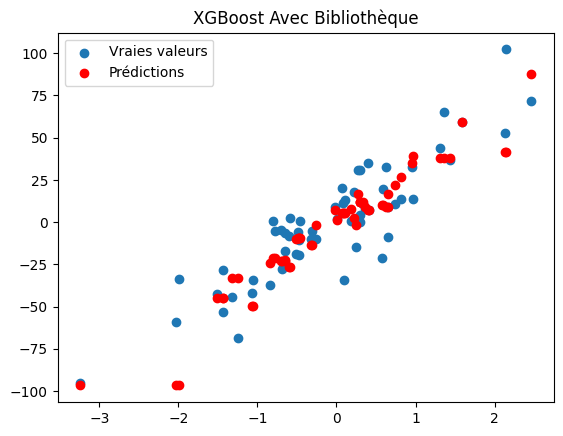

In [19]:
# =========================================================
# XGBOOST AVEC BIBLIOTHEQUE
# =========================================================
# =========================================================

print("========== XGBOOST AVEC BIBLIOTHEQUE ==========")

# ---------------------------------------------------------
# CREATION DU DATASET
# ---------------------------------------------------------

X2, y2 = make_regression(
    n_samples=300,
    n_features=1,
    noise=15,
    random_state=42
)

# ---------------------------------------------------------
# DIVISION TRAIN / TEST
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42
)

# ---------------------------------------------------------
# CREATION DU MODELE
# ---------------------------------------------------------

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# ---------------------------------------------------------
# ENTRAINEMENT
# ---------------------------------------------------------

model.fit(X_train, y_train)

# ---------------------------------------------------------
# PREDICTIONS
# ---------------------------------------------------------

predictions = model.predict(X_test)

# ---------------------------------------------------------
# EVALUATION
# ---------------------------------------------------------

mse = mean_squared_error(y_test, predictions)

print("Erreur MSE :", mse)

# ---------------------------------------------------------
# VISUALISATION
# ---------------------------------------------------------

plt.scatter(X_test, y_test, label="Vraies valeurs")
plt.scatter(X_test, predictions, color='red', label="Prédictions")

plt.title("XGBoost Avec Bibliothèque")
plt.legend()
plt.show()




========== PCA FROM SCRATCH ==========
Dimensions originales : (150, 4)
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]
Matrice de covariance :
[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]
Valeurs propres :
[2.93808505 0.9201649  0.14774182 0.02085386]
Composantes principales :
[[ 0.52106591 -0.37741762]
 [-0.26934744 -0.92329566]
 [ 0.5804131  -0.02449161]
 [ 0.56485654 -0.06694199]]
Nouvelles données PCA :
[[-2.26470281 -0.4800266 ]
 [-2.08096115  0.67413356]
 [-2.36422905  0.34190802]
 [-2.29938422  0.59739451]
 [-2.38984217 -0.64683538]]


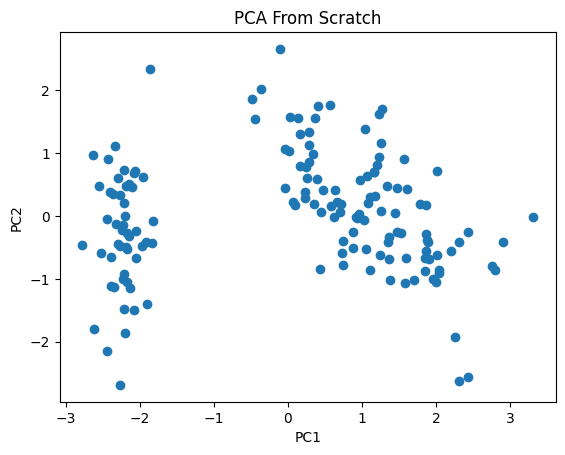

========== PCA AVEC BIBLIOTHEQUE ==========
Dimensions avant PCA : (150, 4)
Dimensions après PCA : (150, 2)
Variance expliquée :
[0.72962445 0.22850762]


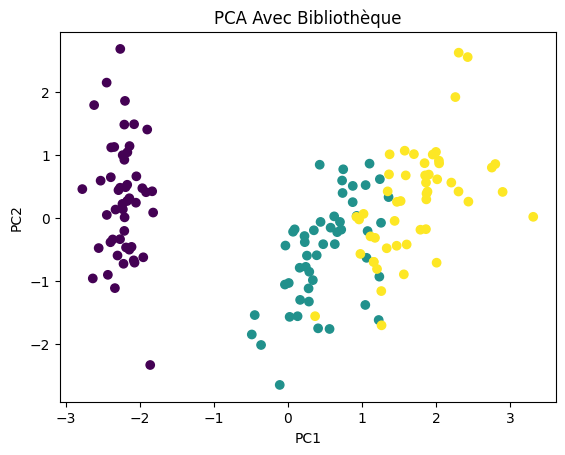

========== FIN ==========


In [20]:
# PCA FROM SCRATCH

# =========================================================
# PCA FROM SCRATCH
# =========================================================
# =========================================================

print("========== PCA FROM SCRATCH ==========")

# ---------------------------------------------------------
# CHARGEMENT DU DATASET IRIS
# ---------------------------------------------------------

iris = load_iris()

# Variables explicatives
X = iris.data

print("Dimensions originales :", X.shape)

# ---------------------------------------------------------
# STANDARDISATION
# ---------------------------------------------------------

# Moyenne
mean = np.mean(X, axis=0)

# Ecart-type
std = np.std(X, axis=0)

# Standardisation
X_standardized = (X - mean) / std

print(X_standardized[:5])

# ---------------------------------------------------------
# MATRICE DE COVARIANCE
# ---------------------------------------------------------

cov_matrix = np.cov(X_standardized.T)

print("Matrice de covariance :")
print(cov_matrix)

# ---------------------------------------------------------
# VALEURS PROPRES ET VECTEURS PROPRES
# ---------------------------------------------------------

eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

print("Valeurs propres :")
print(eigen_values)

# ---------------------------------------------------------
# TRI DES VALEURS PROPRES
# ---------------------------------------------------------

sorted_index = np.argsort(eigen_values)[::-1]

# Réorganisation
eigen_values = eigen_values[sorted_index]
eigen_vectors = eigen_vectors[:, sorted_index]

# ---------------------------------------------------------
# SELECTION DES COMPOSANTES PRINCIPALES
# ---------------------------------------------------------

n_components = 2

principal_components = eigen_vectors[:, :n_components]

print("Composantes principales :")
print(principal_components)

# ---------------------------------------------------------
# PROJECTION DES DONNEES
# ---------------------------------------------------------

X_pca = np.dot(X_standardized, principal_components)

print("Nouvelles données PCA :")
print(X_pca[:5])

# ---------------------------------------------------------
# VISUALISATION
# ---------------------------------------------------------

plt.scatter(X_pca[:,0], X_pca[:,1])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA From Scratch")

plt.show()

# =========================================================
# PCA AVEC BIBLIOTHEQUE
# =========================================================
# =========================================================

print("========== PCA AVEC BIBLIOTHEQUE ==========")

# ---------------------------------------------------------
# CHARGEMENT DU DATASET
# ---------------------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

# ---------------------------------------------------------
# STANDARDISATION
# ---------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ---------------------------------------------------------
# CREATION DU PCA
# ---------------------------------------------------------

pca = PCA(n_components=2)

# ---------------------------------------------------------
# REDUCTION DES DIMENSIONS
# ---------------------------------------------------------

X_pca = pca.fit_transform(X_scaled)

# ---------------------------------------------------------
# AFFICHAGE DES DIMENSIONS
# ---------------------------------------------------------

print("Dimensions avant PCA :", X.shape)
print("Dimensions après PCA :", X_pca.shape)

# ---------------------------------------------------------
# VARIANCE EXPLIQUEE
# ---------------------------------------------------------

print("Variance expliquée :")
print(pca.explained_variance_ratio_)

# ---------------------------------------------------------
# VISUALISATION
# ---------------------------------------------------------

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Avec Bibliothèque")

plt.show()


print("========== FIN ==========")


